
# Validação experimental — Ensaio DT 10 ,15 , 22 Ω (`log_024.csv`,`log_025.csv``log_026.csv`)

Notebook pronto a usar para validar o ensaio experimental com firmware DT.

Objetivos:
- ler o CSV do ensaio;
- confirmar início em OCV (`I_mA ≈ 0`);
- identificar período com carga ligada;
- gerar gráficos de tensão, corrente, temperatura e SoC;
- comparar `SoC_fw`, `SoC_ml` e `SoC_max`;
- calcular erro do DT (`SoC_ml`) face ao `SoC_fw`;
- assinalar Patamar 1 e Patamar 2;
- exportar figuras e tabela resumo para usar no relatório.

> Para usar com outro CSV, basta alterar `CSV_PATH` e, se necessário, os tempos dos patamares.


In [1]:
# ============================================================
# 1) CONFIGURAÇÃO MULTI-ENSAIO
# ============================================================

CAPACIDADE_AH = 2.6
I_ON_THRESHOLD_MA = 50

OUTPUT_DIR = "resultados_validacao_DT_multiresistencia"

# Colocar aqui os CSVs dos ensaios.
# O 22 ohm deve ser atualizado quando souberes o caminho exato no Kaggle.
ENSAIOS = [
    {
        "nome": "DT pkl — 10 ohm",
        "resistencia_ohm": 10,
        "csv_path": "/kaggle/input/datasets/manuelcoelho7/csv-log-024-dt-pkl/log_024.csv",
        "patamar_1_t_s": 195,
        "patamar_2_t_s": 3562,
    },
    {
        "nome": "DT pkl — 22 ohm",
        "resistencia_ohm": 22,
        "csv_path": "/kaggle/input/datasets/manuelcoelho7/ensaio-dt-pkl-22-ohms/log_025.csv",
        "patamar_1_t_s": 161,      # substituir depois pelo tempo real do patamar 1
        "patamar_2_t_s": 3212,      # substituir depois pelo tempo real do patamar 2
    },

    
     {
        "nome": "DT pkl — 15 ohm",
         "resistencia_ohm": 15,
         "csv_path": "/kaggle/input/datasets/manuelcoelho7/ensaio-dt-pkl-15-ohms/log_026.csv",
         "patamar_1_t_s": 161,
         "patamar_2_t_s": 3618,
     },
]

In [2]:
# ============================================================
# 2) IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [3]:
# ============================================================
# 3) LEITURA ROBUSTA DOS CSVs
# ============================================================

COLS_DT = [
    "t_s",
    "Vbus_V",
    "Vshunt_mV",
    "I_mA",
    "P_mW",
    "Vmeas_V",
    "Vbat_V",
    "T_C",
    "I_model_A",
    "I_cc_A",
    "dV_dt",
    "dI_dt",
    "SoC_fw",
    "SOC0_OCV",
    "Ah_acc",
    "SoC_ml",
    "SoC_max",
    "Vcell_max_V",
    "MAX_ok",
]

def ler_csv_dt(csv_path):
    """
    Lê CSV do firmware DT.
    Aceita:
    - CSV com cabeçalho normal;
    - CSV com primeira linha de comentário/OCV e depois cabeçalho;
    - CSV sem cabeçalho.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"CSV não encontrado:\n{csv_path}\n\n"
            "Confirma o caminho no painel /kaggle/input ou usa uma célula auxiliar para listar CSVs."
        )

    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        linhas = [f.readline().strip() for _ in range(5)]

    primeira = linhas[0]
    segunda = linhas[1] if len(linhas) > 1 else ""

    if primeira.startswith("t_s"):
        df = pd.read_csv(csv_path)
    elif segunda.startswith("t_s"):
        df = pd.read_csv(csv_path, skiprows=1)
    else:
        df = pd.read_csv(csv_path, header=None, names=COLS_DT, comment="#")

    df.columns = [c.strip() for c in df.columns]

    # Remover linhas inválidas
    if "t_s" in df.columns:
        df = df[pd.to_numeric(df["t_s"], errors="coerce").notna()].copy()

    # Converter para numérico sempre que possível
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


dfs = []

for ensaio in ENSAIOS:
    nome = ensaio["nome"]
    csv_path = ensaio["csv_path"]

    print("=" * 80)
    print("A ler:", nome)
    print("CSV:", csv_path)

    df_i = ler_csv_dt(csv_path)

    df_i["ensaio"] = nome
    df_i["resistencia_ohm"] = ensaio["resistencia_ohm"]
    df_i["patamar_1_t_s"] = ensaio["patamar_1_t_s"]
    df_i["patamar_2_t_s"] = ensaio["patamar_2_t_s"]

    dfs.append(df_i)

    print("Linhas:", len(df_i))
    print("Colunas:", list(df_i.columns))
    display(df_i.head())
    display(df_i.tail())

df_all = pd.concat(dfs, ignore_index=True)

print("\nResumo geral:")
print("Total de linhas:", len(df_all))
print("Ensaios:", df_all["ensaio"].unique())
display(df_all.head())

A ler: DT pkl — 10 ohm
CSV: /kaggle/input/datasets/manuelcoelho7/csv-log-024-dt-pkl/log_024.csv
Linhas: 6894
Colunas: ['t_s', 'Vbus_V', 'Vshunt_mV', 'I_mA', 'P_mW', 'Vmeas_V', 'Vbat_V', 'T_C', 'I_model_A', 'I_cc_A', 'dV_dt', 'dI_dt', 'SoC_fw', 'SOC0_OCV', 'Ah_acc', 'SoC_ml', 'SoC_max', 'Vcell_max_V', 'MAX_ok', 'ensaio', 'resistencia_ohm', 'patamar_1_t_s', 'patamar_2_t_s']


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,I_model_A,I_cc_A,dV_dt,dI_dt,SoC_fw,SOC0_OCV,Ah_acc,SoC_ml,SoC_max,Vcell_max_V,MAX_ok,ensaio,resistencia_ohm,patamar_1_t_s,patamar_2_t_s
0,0.010,0.016,-0.03,-0.1,0.0,1.9160,3.8320,26.69,-0.0001,-0.0001,NaN,NaN,0.68275,0.68275,-0.0,0.315275,0.540977,3.8450,1,DT pkl — 10 ohm,10,195,3562
1,0.548,0.016,-0.06,-0.6,0.0,1.9158,3.8315,26.69,-0.0006,-0.0006,-0.000929,-0.000929,0.68275,0.68275,-0.0,0.315275,0.540977,3.8437,1,DT pkl — 10 ohm,10,195,3562
2,1.085,0.012,-0.04,-0.3,0.0,1.9161,3.8323,26.75,-0.0003,-0.0003,0.001396,0.000559,0.68275,0.68275,-0.0,0.315275,0.540977,3.8437,1,DT pkl — 10 ohm,10,195,3562
3,1.623,0.016,-0.03,-0.3,0.0,1.9155,3.8310,26.75,-0.0003,-0.0003,-0.002323,0.000000,0.68275,0.68275,-0.0,0.315275,0.540977,3.8437,1,DT pkl — 10 ohm,10,195,3562
4,2.160,0.012,-0.02,-0.1,0.0,1.9156,3.8313,26.81,-0.0001,-0.0001,0.000466,0.000372,0.68275,0.68275,-0.0,0.315275,0.540977,3.8425,1,DT pkl — 10 ohm,10,195,3562


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,I_model_A,I_cc_A,dV_dt,dI_dt,SoC_fw,SOC0_OCV,Ah_acc,SoC_ml,SoC_max,Vcell_max_V,MAX_ok,ensaio,resistencia_ohm,patamar_1_t_s,patamar_2_t_s
6889,3703.051,0.016,-0.01,-0.1,0.0,1.8556,3.7113,26.50,-0.0001,-0.0001,-0.003258,0.000372,0.55486,0.68275,0.332513,0.523712,0.102578,3.7175,1,DT pkl — 10 ohm,10,195,3562
6890,3703.589,0.012,0.00,-0.2,0.0,1.8550,3.7100,26.50,-0.0002,-0.0002,-0.002323,-0.000186,0.55486,0.68275,0.332512,0.523712,0.102578,3.7162,1,DT pkl — 10 ohm,10,195,3562
6891,3704.127,0.016,-0.02,0.0,0.0,1.8526,3.7053,26.56,0.0000,0.0000,-0.008832,0.000372,0.55486,0.68275,0.332512,0.523712,0.102578,3.7175,1,DT pkl — 10 ohm,10,195,3562
6892,3704.664,0.012,-0.03,-0.2,0.0,1.8503,3.7005,26.50,-0.0002,-0.0002,-0.008844,-0.000372,0.55486,0.68275,0.332512,0.523712,0.102578,3.7175,1,DT pkl — 10 ohm,10,195,3562
6893,3705.202,0.012,-0.01,-0.4,0.0,1.8483,3.6965,26.50,-0.0004,-0.0004,-0.007437,-0.000372,0.55486,0.68275,0.332512,0.523712,0.102578,3.7175,1,DT pkl — 10 ohm,10,195,3562


A ler: DT pkl — 22 ohm
CSV: /kaggle/input/datasets/manuelcoelho7/ensaio-dt-pkl-22-ohms/log_025.csv
Linhas: 6360
Colunas: ['t_s', 'Vbus_V', 'Vshunt_mV', 'I_mA', 'P_mW', 'Vmeas_V', 'Vbat_V', 'T_C', 'I_model_A', 'I_cc_A', 'dV_dt', 'dI_dt', 'SoC_fw', 'SOC0_OCV', 'Ah_acc', 'SoC_ml', 'SoC_max', 'Vcell_max_V', 'MAX_ok', 'ensaio', 'resistencia_ohm', 'patamar_1_t_s', 'patamar_2_t_s']


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,I_model_A,I_cc_A,dV_dt,dI_dt,SoC_fw,SOC0_OCV,Ah_acc,SoC_ml,SoC_max,Vcell_max_V,MAX_ok,ensaio,resistencia_ohm,patamar_1_t_s,patamar_2_t_s
0,0.010,0.012,0.00,-0.3,0.0,1.8845,3.769,27.37,-0.0003,-0.0003,NaN,NaN,0.60643,0.60643,-0.0,0.355633,0.350586,3.7800,1,DT pkl — 22 ohm,22,161,3212
1,0.548,0.016,0.03,0.1,0.0,1.8845,3.769,27.44,0.0001,0.0001,0.000000,0.000743,0.60643,0.60643,0.0,0.478357,0.350586,3.7812,1,DT pkl — 22 ohm,22,161,3212
2,1.085,0.016,-0.03,-0.3,0.0,1.8835,3.767,27.44,-0.0003,-0.0003,-0.003725,-0.000745,0.60643,0.60643,-0.0,0.478357,0.350586,3.7812,1,DT pkl — 22 ohm,22,161,3212
3,1.623,0.012,0.00,0.0,0.0,1.8835,3.767,27.44,0.0000,0.0000,0.000000,0.000558,0.60643,0.60643,-0.0,0.478357,0.350586,3.7825,1,DT pkl — 22 ohm,22,161,3212
4,2.160,0.016,-0.01,-0.5,0.0,1.8840,3.768,27.44,-0.0005,-0.0005,0.001862,-0.000931,0.60643,0.60643,-0.0,0.478357,0.350586,3.7812,1,DT pkl — 22 ohm,22,161,3212


...

A ler: DT pkl — 15 ohm
CSV: /kaggle/input/datasets/manuelcoelho7/ensaio-dt-pkl-15-ohms/log_026.csv
Linhas: 6990
Colunas: ['t_s', 'Vbus_V', 'Vshunt_mV', 'I_mA', 'P_mW', 'Vmeas_V', 'Vbat_V', 'T_C', 'I_model_A', 'I_cc_A', 'dV_dt', 'dI_dt', 'SoC_fw', 'SOC0_OCV', 'Ah_acc', 'SoC_ml', 'SoC_max', 'Vcell_max_V', 'MAX_ok', 'ensaio', 'resistencia_ohm', 'patamar_1_t_s', 'patamar_2_t_s']


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,I_model_A,I_cc_A,dV_dt,dI_dt,SoC_fw,SOC0_OCV,Ah_acc,SoC_ml,SoC_max,Vcell_max_V,MAX_ok,ensaio,resistencia_ohm,patamar_1_t_s,patamar_2_t_s
0,0.010,0.012,-0.02,0.1,0.0,1.8781,3.7563,27.75,0.0001,0.0001,NaN,NaN,0.59571,0.59571,0.0,0.355633,0.325508,3.7725,1,DT pkl — 15 ohm,15,161,3618
1,0.548,0.012,-0.02,-0.1,0.0,1.8778,3.7555,27.75,-0.0001,-0.0001,-0.001394,-0.000372,0.59571,0.59571,-0.0,0.478357,0.325508,3.7738,1,DT pkl — 15 ohm,15,161,3618
2,1.085,0.016,-0.02,0.1,0.0,1.8786,3.7573,27.81,0.0001,0.0001,0.003259,0.000372,0.59571,0.59571,0.0,0.478357,0.325508,3.7738,1,DT pkl — 15 ohm,15,161,3618
3,1.623,0.016,-0.03,-0.2,0.0,1.8813,3.7625,27.87,-0.0002,-0.0002,0.009759,-0.000558,0.59571,0.59571,-0.0,0.478357,0.325508,3.7738,1,DT pkl — 15 ohm,15,161,3618
4,2.160,0.016,-0.06,-0.4,0.0,1.8834,3.7668,27.87,-0.0004,-0.0004,0.007914,-0.000372,0.59571,0.59571,-0.0,0.478357,0.325508,3.7738,1,DT pkl — 15 ohm,15,161,3618


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,I_model_A,I_cc_A,dV_dt,dI_dt,SoC_fw,SOC0_OCV,Ah_acc,SoC_ml,SoC_max,Vcell_max_V,MAX_ok,ensaio,resistencia_ohm,patamar_1_t_s,patamar_2_t_s
6985,3754.797,0.012,-0.01,-0.3,0.0,1.8335,3.6670,28.31,-0.0003,-0.0003,0.001858,-0.000558,0.50734,0.59571,0.229774,0.523712,0.079648,3.6837,1,DT pkl — 15 ohm,15,161,3618
6986,3755.334,0.016,-0.03,0.2,0.0,1.8345,3.6690,28.31,0.0002,0.0002,0.003726,0.000931,0.50734,0.59571,0.229774,0.523712,0.079648,3.6825,1,DT pkl — 15 ohm,15,161,3618
6987,3755.872,0.012,-0.04,-0.4,0.0,1.8380,3.6760,28.31,-0.0004,-0.0004,0.013009,-0.001115,0.50734,0.59571,0.229774,0.523712,0.079648,3.6837,1,DT pkl — 15 ohm,15,161,3618
6988,3756.410,0.016,-0.01,-0.2,0.0,1.8374,3.6748,28.25,-0.0002,-0.0002,-0.002324,0.000372,0.50734,0.59571,0.229774,0.523712,0.079648,3.6837,1,DT pkl — 15 ohm,15,161,3618
6989,3756.947,0.012,-0.03,-0.3,0.0,1.8389,3.6778,28.25,-0.0003,-0.0003,0.005585,-0.000186,0.50734,0.59571,0.229774,0.523712,0.079648,3.6837,1,DT pkl — 15 ohm,15,161,3618



Resumo geral:
Total de linhas: 20244
Ensaios: ['DT pkl — 10 ohm' 'DT pkl — 22 ohm' 'DT pkl — 15 ohm']


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,I_model_A,I_cc_A,dV_dt,dI_dt,SoC_fw,SOC0_OCV,Ah_acc,SoC_ml,SoC_max,Vcell_max_V,MAX_ok,ensaio,resistencia_ohm,patamar_1_t_s,patamar_2_t_s
0,0.010,0.016,-0.03,-0.1,0.0,1.9160,3.8320,26.69,-0.0001,-0.0001,NaN,NaN,0.68275,0.68275,-0.0,0.315275,0.540977,3.8450,1,DT pkl — 10 ohm,10,195,3562
1,0.548,0.016,-0.06,-0.6,0.0,1.9158,3.8315,26.69,-0.0006,-0.0006,-0.000929,-0.000929,0.68275,0.68275,-0.0,0.315275,0.540977,3.8437,1,DT pkl — 10 ohm,10,195,3562
2,1.085,0.012,-0.04,-0.3,0.0,1.9161,3.8323,26.75,-0.0003,-0.0003,0.001396,0.000559,0.68275,0.68275,-0.0,0.315275,0.540977,3.8437,1,DT pkl — 10 ohm,10,195,3562
3,1.623,0.016,-0.03,-0.3,0.0,1.9155,3.8310,26.75,-0.0003,-0.0003,-0.002323,0.000000,0.68275,0.68275,-0.0,0.315275,0.540977,3.8437,1,DT pkl — 10 ohm,10,195,3562
4,2.160,0.012,-0.02,-0.1,0.0,1.9156,3.8313,26.81,-0.0001,-0.0001,0.000466,0.000372,0.68275,0.68275,-0.0,0.315275,0.540977,3.8425,1,DT pkl — 10 ohm,10,195,3562


In [4]:
# ============================================================
# 4) PROCESSAMENTO — CARGA LIGADA E TEMPO RELATIVO
# ============================================================

df_all = df_all.copy()

# Considerar carga ligada quando |I_mA| ultrapassa o limiar
df_all["carga_ligada"] = df_all["I_mA"].abs() > I_ON_THRESHOLD_MA

# Criar tempo relativo ao início da carga para cada ensaio
df_all["t_rel_carga_s"] = np.nan

for nome, g in df_all.groupby("ensaio"):
    idx = g.index
    g_on = g[g["carga_ligada"]]

    if len(g_on) > 0:
        t0 = g_on["t_s"].iloc[0]
        df_all.loc[idx, "t_rel_carga_s"] = df_all.loc[idx, "t_s"] - t0
    else:
        df_all.loc[idx, "t_rel_carga_s"] = df_all.loc[idx, "t_s"]

display(df_all[["ensaio", "t_s", "t_rel_carga_s", "I_mA", "Vbat_V", "SoC_fw", "SoC_ml", "SoC_max", "carga_ligada"]].head(20))

,ensaio,t_s,t_rel_carga_s,I_mA,Vbat_V,SoC_fw,SoC_ml,SoC_max,carga_ligada
0,DT pkl — 10 ohm,0.010,-91.920,-0.1,3.8320,0.68275,0.315275,0.540977,False
1,DT pkl — 10 ohm,0.548,-91.382,-0.6,3.8315,0.68275,0.315275,0.540977,False
2,DT pkl — 10 ohm,1.085,-90.845,-0.3,3.8323,0.68275,0.315275,0.540977,False
3,DT pkl — 10 ohm,1.623,-90.307,-0.3,3.8310,0.68275,0.315275,0.540977,False
4,DT pkl — 10 ohm,2.160,-89.770,-0.1,3.8313,0.68275,0.315275,0.540977,False
5,DT pkl — 10 ohm,2.698,-89.232,-0.2,3.8320,0.68275,0.315275,0.540977,False
6,DT pkl — 10 ohm,3.235,-88.695,0.0,3.8300,0.68275,0.315275,0.540977,False
7,DT pkl — 10 ohm,3.773,-88.157,0.0,3.8333,0.68275,0.315275,0.540977,False
8,DT pkl — 10 ohm,4.310,-87.620,-0.1,3.8308,0.68275,0.315275,0.540977,False
9,DT pkl — 10 ohm,4.848,-87.082,-0.3,3.8295,0.68275,0.315275,0.540977,False


In [5]:
# ============================================================
# 5) RESUMO POR ENSAIO
# ============================================================

resumos = []

for nome, g in df_all.groupby("ensaio"):
    g_on = g[g["carga_ligada"]].copy()

    if len(g_on) == 0:
        continue

    resumo = {
        "ensaio": nome,
        "R_ohm": g["resistencia_ohm"].iloc[0],
        "linhas_total": len(g),
        "linhas_carga": len(g_on),
        "t_total_s": g["t_s"].max() - g["t_s"].min(),
        "t_carga_s": g_on["t_s"].max() - g_on["t_s"].min(),
        "I_mA_medio_carga": g_on["I_mA"].mean(),
        "I_mA_min_carga": g_on["I_mA"].min(),
        "I_mA_max_carga": g_on["I_mA"].max(),
        "Vbat_inicio_carga": g_on["Vbat_V"].iloc[0],
        "Vbat_fim_carga": g_on["Vbat_V"].iloc[-1],
        "SoC_fw_inicio": g_on["SoC_fw"].iloc[0],
        "SoC_fw_fim": g_on["SoC_fw"].iloc[-1],
        "SoC_ml_inicio": g_on["SoC_ml"].iloc[0],
        "SoC_ml_fim": g_on["SoC_ml"].iloc[-1],
        "SoC_max_inicio": g_on["SoC_max"].iloc[0] if "SoC_max" in g_on.columns else np.nan,
        "SoC_max_fim": g_on["SoC_max"].iloc[-1] if "SoC_max" in g_on.columns else np.nan,
        "Ah_acc_fim": g_on["Ah_acc"].iloc[-1] if "Ah_acc" in g_on.columns else np.nan,
        "T_C_media": g_on["T_C"].mean() if "T_C" in g_on.columns else np.nan,
    }

    resumos.append(resumo)

df_resumo = pd.DataFrame(resumos)

display(df_resumo)

df_resumo.to_csv(os.path.join(OUTPUT_DIR, "resumo_ensaios.csv"), index=False)

,ensaio,R_ohm,linhas_total,linhas_carga,t_total_s,t_carga_s,I_mA_medio_carga,I_mA_min_carga,I_mA_max_carga,Vbat_inicio_carga,Vbat_fim_carga,SoC_fw_inicio,SoC_fw_fim,SoC_ml_inicio,SoC_ml_fim,SoC_max_inicio,SoC_max_fim,Ah_acc_fim,T_C_media
0,DT pkl — 10 ohm,10,6894,6683,3705.192,3591.768,333.233578,321.9,342.6,3.6795,3.5615,0.68273,0.55486,0.523712,0.744427,0.540977,0.102578,0.332514,26.721499
1,DT pkl — 15 ohm,15,6990,6762,3756.937,3729.922,227.564611,219.6,232.1,3.6858,3.6025,0.59570,0.50734,0.523712,0.646039,0.325508,0.078437,0.229776,28.066216
2,DT pkl — 22 ohm,22,6360,6045,3418.377,3337.087,160.397883,157.8,162.6,3.7290,3.6848,0.60642,0.55074,0.523712,0.523712,0.350586,0.205195,0.144779,27.615481


In [6]:
# ============================================================
# 6) MÉTRICAS — SoC_ml vs SoC_fw
# ============================================================

metricas = []

for nome, g in df_all.groupby("ensaio"):
    g_on = g[g["carga_ligada"]].copy()

    cols_necessarias = ["SoC_fw", "SoC_ml"]
    if not all(c in g_on.columns for c in cols_necessarias):
        continue

    g_valid = g_on.dropna(subset=["SoC_fw", "SoC_ml"])

    if len(g_valid) == 0:
        continue

    erro = g_valid["SoC_ml"] - g_valid["SoC_fw"]

    metricas.append({
        "ensaio": nome,
        "R_ohm": g["resistencia_ohm"].iloc[0],
        "n_amostras": len(g_valid),
        "MAE": np.mean(np.abs(erro)),
        "RMSE": np.sqrt(np.mean(erro**2)),
        "bias": np.mean(erro),
        "erro_min": erro.min(),
        "erro_max": erro.max(),
    })

df_metricas = pd.DataFrame(metricas)

display(df_metricas)

df_metricas.to_csv(os.path.join(OUTPUT_DIR, "metricas_soc_ml_vs_soc_fw.csv"), index=False)

,ensaio,R_ohm,n_amostras,MAE,RMSE,bias,erro_min,erro_max
0,DT pkl — 10 ohm,10,6683,0.140604,0.143525,0.079973,-0.201153,0.330513
1,DT pkl — 15 ohm,15,6762,0.077249,0.087140,0.024111,-0.237587,0.378703
2,DT pkl — 22 ohm,22,6045,0.054842,0.057154,-0.054842,-0.127063,-0.027028


In [7]:
# ============================================================
# 7) TABELA DOS PATAMARES
# ============================================================

linhas_patamares = []

for ensaio in ENSAIOS:
    nome = ensaio["nome"]
    g = df_all[df_all["ensaio"] == nome].copy()

    if len(g) == 0:
        continue

    for etiqueta, t_ref in [
        ("Patamar 1", ensaio["patamar_1_t_s"]),
        ("Patamar 2", ensaio["patamar_2_t_s"]),
    ]:
        if t_ref is None or t_ref <= 0:
            continue

        idx = (g["t_s"] - t_ref).abs().idxmin()
        row = g.loc[idx]

        linhas_patamares.append({
            "ensaio": nome,
            "R_ohm": ensaio["resistencia_ohm"],
            "patamar": etiqueta,
            "t_ref_s": t_ref,
            "t_csv_s": row.get("t_s", np.nan),
            "I_mA": row.get("I_mA", np.nan),
            "Vbat_V": row.get("Vbat_V", np.nan),
            "Vmeas_V": row.get("Vmeas_V", np.nan),
            "T_C": row.get("T_C", np.nan),
            "SoC_fw": row.get("SoC_fw", np.nan),
            "SoC_ml": row.get("SoC_ml", np.nan),
            "SoC_max": row.get("SoC_max", np.nan),
            "Ah_acc": row.get("Ah_acc", np.nan),
        })

df_patamares = pd.DataFrame(linhas_patamares)

display(df_patamares)

df_patamares.to_csv(os.path.join(OUTPUT_DIR, "tabela_patamares.csv"), index=False)

,ensaio,R_ohm,patamar,t_ref_s,t_csv_s,I_mA,Vbat_V,Vmeas_V,T_C,SoC_fw,SoC_ml,SoC_max,Ah_acc
0,DT pkl — 10 ohm,10,Patamar 1,195,195.133,333.3,3.6413,1.8206,26.75,0.67901,0.523712,0.530820,0.009712
1,DT pkl — 10 ohm,10,Patamar 2,3562,3562.211,329.7,3.5860,1.7930,26.56,0.55913,0.744427,0.112930,0.321424
2,DT pkl — 22 ohm,22,Patamar 1,161,160.740,160.9,3.7288,1.8644,27.56,0.60528,0.523712,0.350586,0.002990
3,DT pkl — 22 ohm,22,Patamar 2,3212,3211.944,160.6,3.6858,1.8429,27.81,0.55301,0.523712,0.209492,0.138890
4,DT pkl — 15 ohm,15,Patamar 1,161,161.211,229.5,3.6953,1.8476,28.00,0.59410,0.523712,0.321211,0.004194
5,DT pkl — 15 ohm,15,Patamar 2,3618,3618.246,224.0,3.5818,1.7909,28.12,0.51003,0.646039,0.087031,0.222784


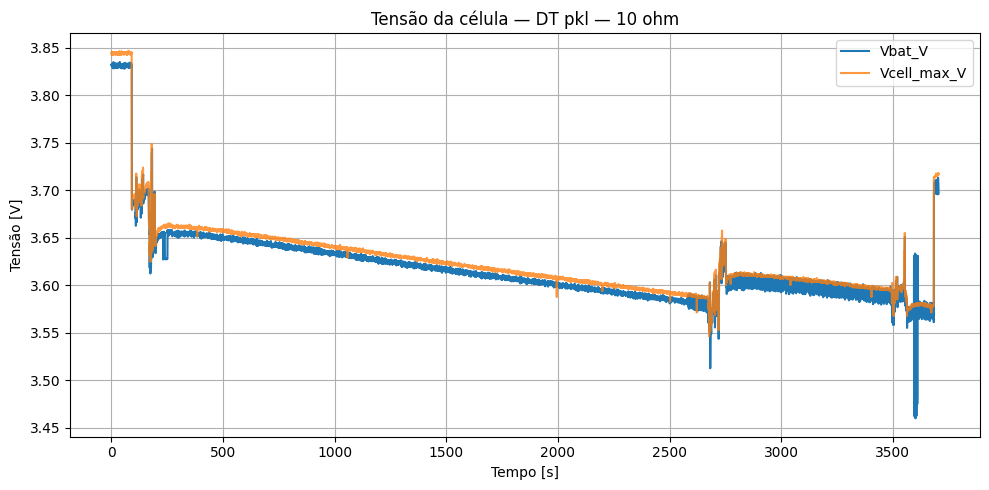

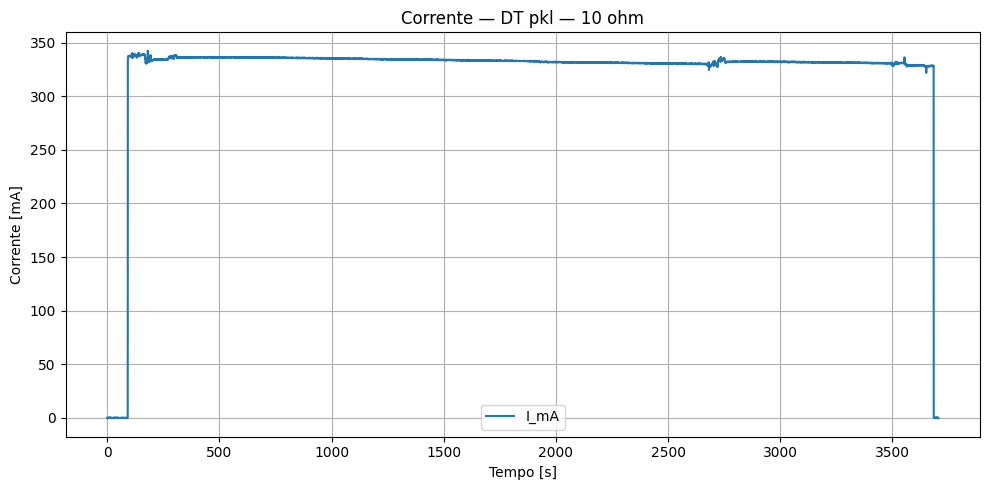

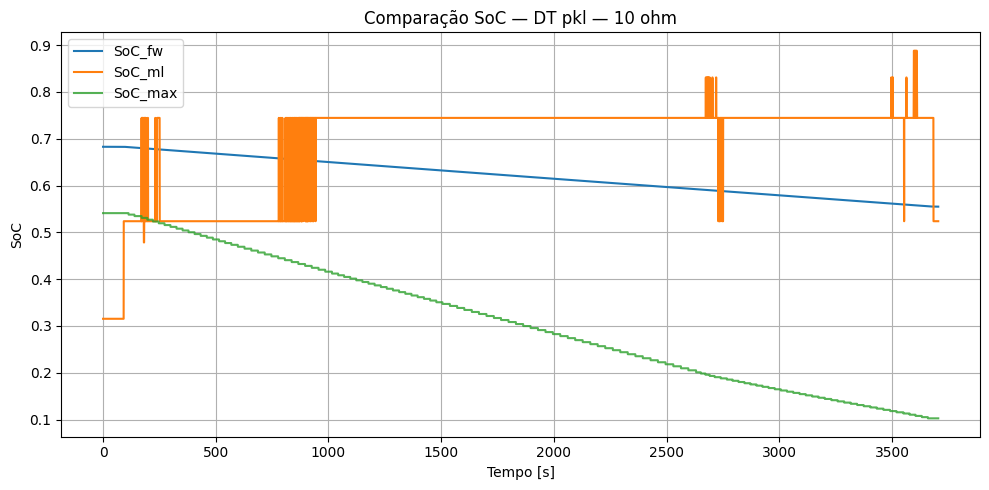

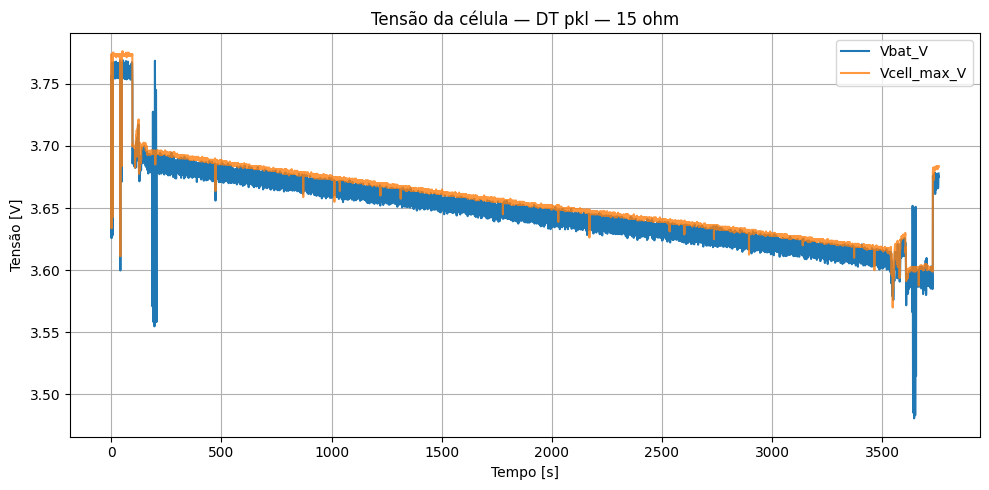

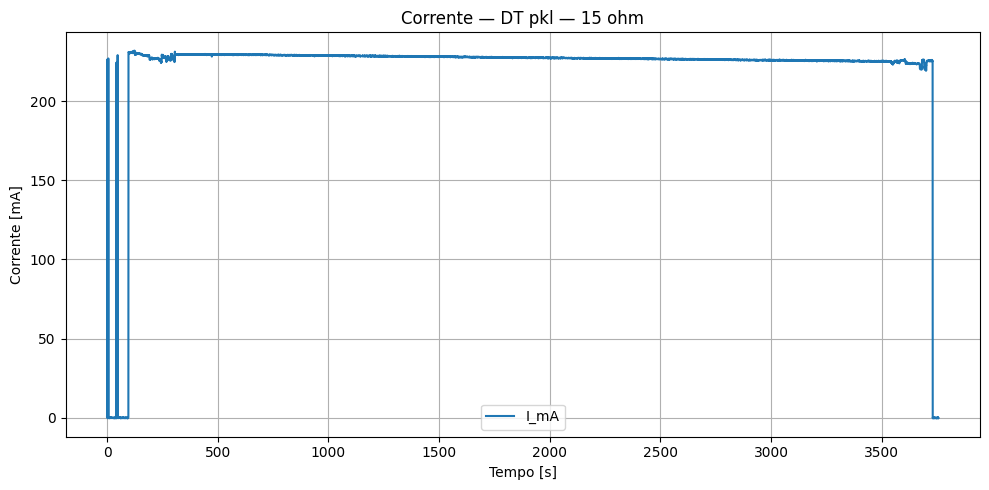

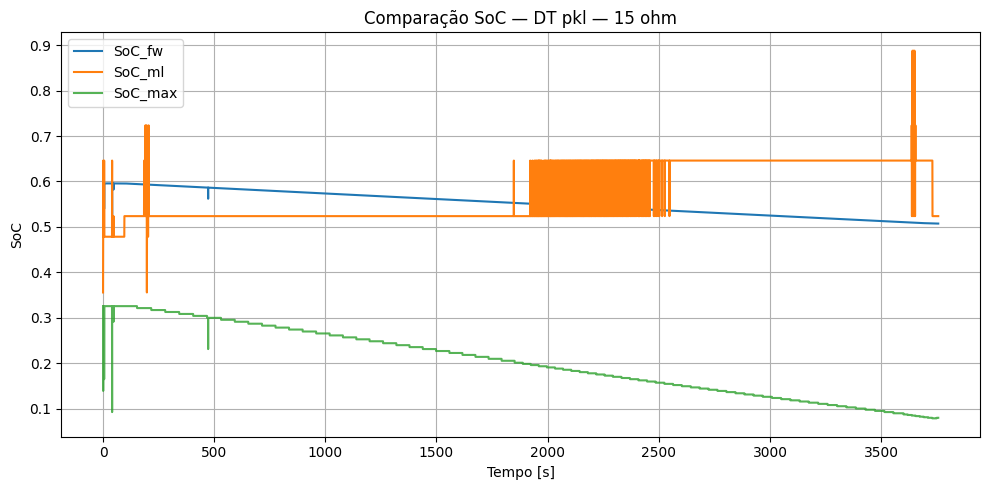

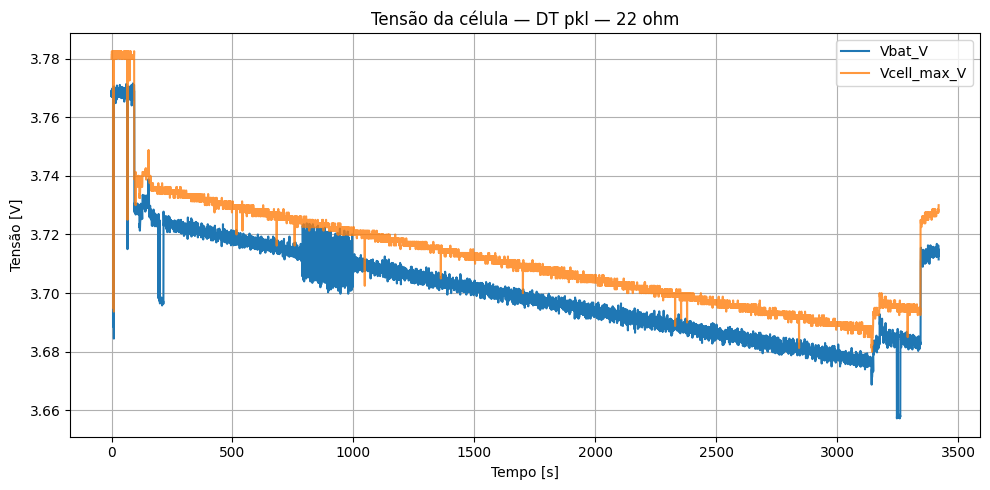

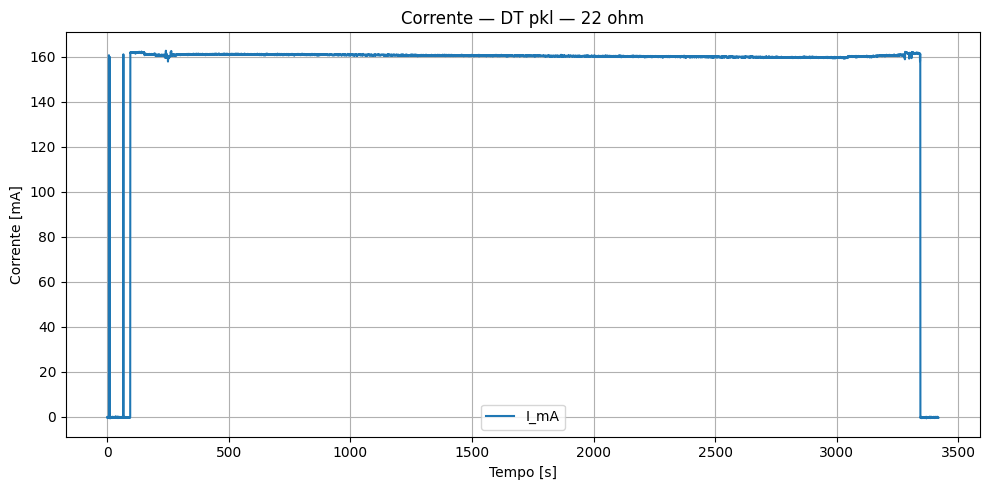

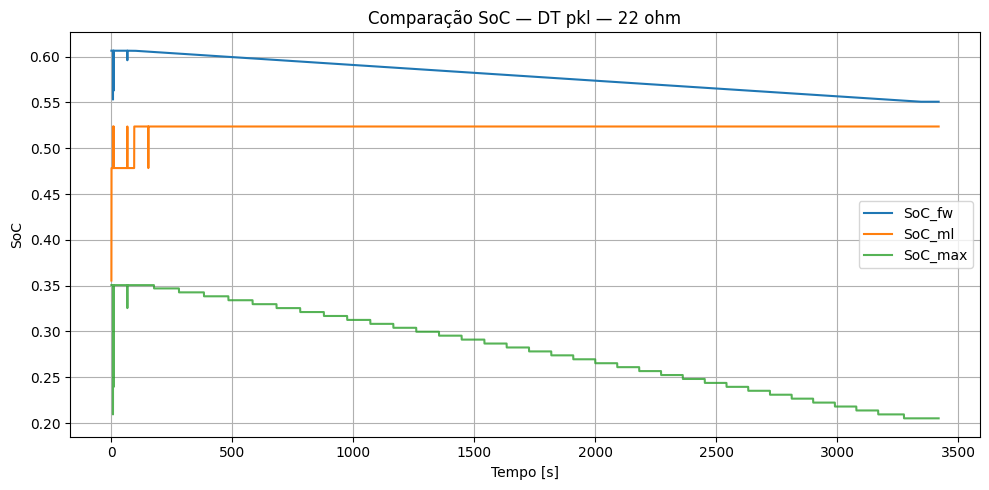

In [8]:
# ============================================================
# 8) GRÁFICOS POR ENSAIO
# ============================================================

for nome, g in df_all.groupby("ensaio"):
    g = g.sort_values("t_s").copy()

    # Tensão
    plt.figure(figsize=(10, 5))
    plt.plot(g["t_s"], g["Vbat_V"], label="Vbat_V")
    if "Vcell_max_V" in g.columns:
        plt.plot(g["t_s"], g["Vcell_max_V"], label="Vcell_max_V", alpha=0.8)
    plt.xlabel("Tempo [s]")
    plt.ylabel("Tensão [V]")
    plt.title(f"Tensão da célula — {nome}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"tensao_{nome.replace(' ', '_').replace('—','-')}.png"), dpi=150)
    plt.show()

    # Corrente
    plt.figure(figsize=(10, 5))
    plt.plot(g["t_s"], g["I_mA"], label="I_mA")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Corrente [mA]")
    plt.title(f"Corrente — {nome}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"corrente_{nome.replace(' ', '_').replace('—','-')}.png"), dpi=150)
    plt.show()

    # SoC
    plt.figure(figsize=(10, 5))
    plt.plot(g["t_s"], g["SoC_fw"], label="SoC_fw")
    plt.plot(g["t_s"], g["SoC_ml"], label="SoC_ml")
    if "SoC_max" in g.columns:
        plt.plot(g["t_s"], g["SoC_max"], label="SoC_max", alpha=0.8)
    plt.xlabel("Tempo [s]")
    plt.ylabel("SoC")
    plt.title(f"Comparação SoC — {nome}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"soc_{nome.replace(' ', '_').replace('—','-')}.png"), dpi=150)
    plt.show()

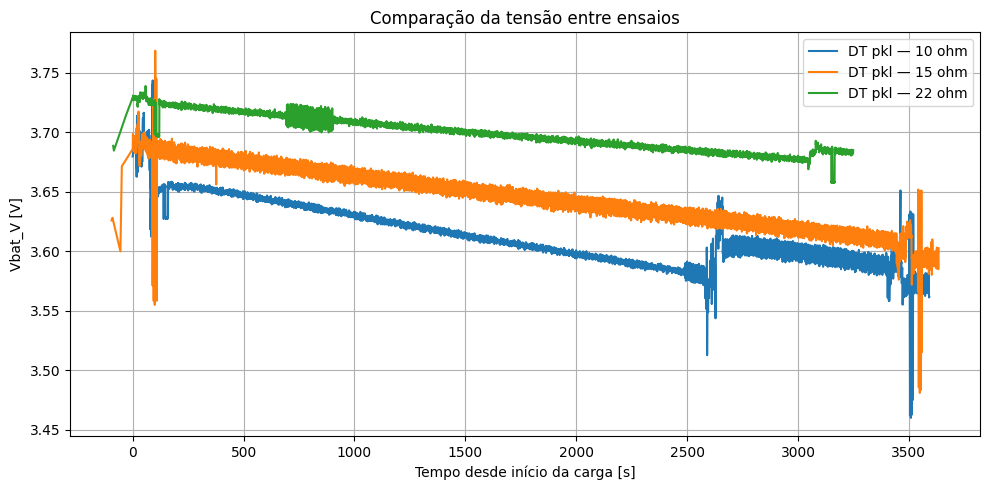

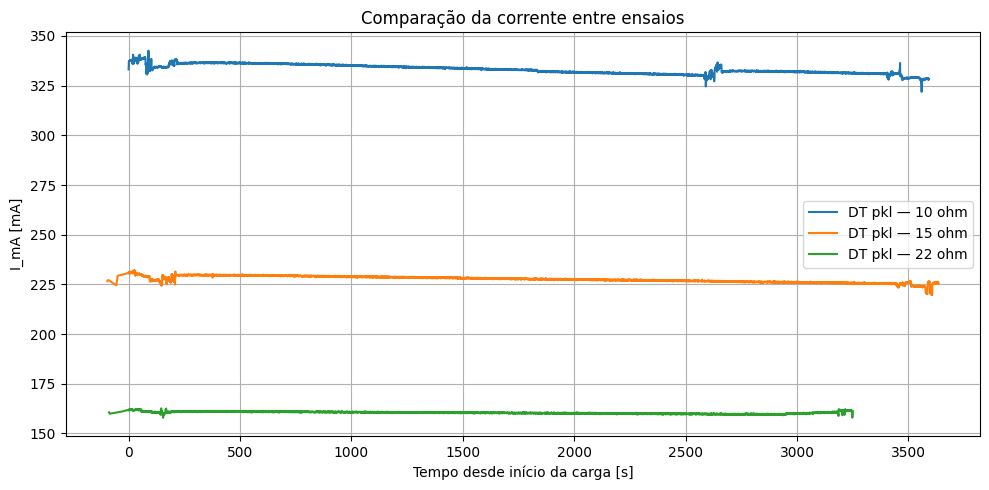

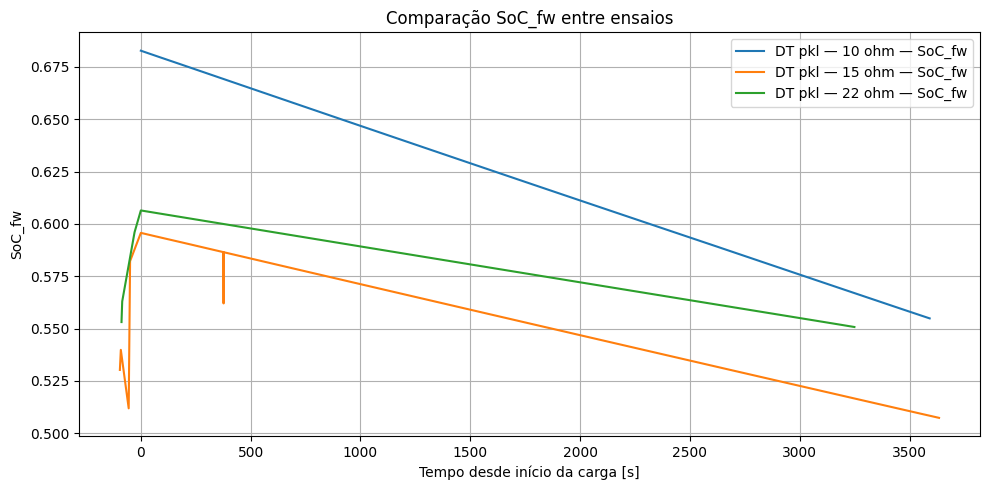

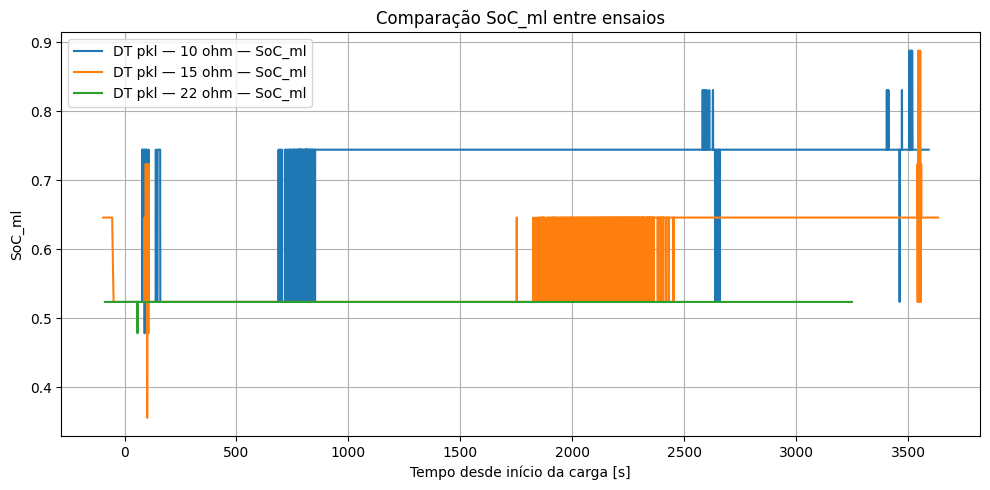

In [9]:
# ============================================================
# 9) GRÁFICOS COMPARATIVOS ENTRE ENSAIOS
# ============================================================

# Comparação Vbat vs tempo relativo à carga
plt.figure(figsize=(10, 5))
for nome, g in df_all.groupby("ensaio"):
    g_on = g[g["carga_ligada"]].sort_values("t_rel_carga_s")
    plt.plot(g_on["t_rel_carga_s"], g_on["Vbat_V"], label=nome)

plt.xlabel("Tempo desde início da carga [s]")
plt.ylabel("Vbat_V [V]")
plt.title("Comparação da tensão entre ensaios")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparacao_vbat_multiresistencia.png"), dpi=150)
plt.show()


# Comparação corrente vs tempo relativo à carga
plt.figure(figsize=(10, 5))
for nome, g in df_all.groupby("ensaio"):
    g_on = g[g["carga_ligada"]].sort_values("t_rel_carga_s")
    plt.plot(g_on["t_rel_carga_s"], g_on["I_mA"], label=nome)

plt.xlabel("Tempo desde início da carga [s]")
plt.ylabel("I_mA [mA]")
plt.title("Comparação da corrente entre ensaios")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparacao_corrente_multiresistencia.png"), dpi=150)
plt.show()


# Comparação SoC_fw
plt.figure(figsize=(10, 5))
for nome, g in df_all.groupby("ensaio"):
    g_on = g[g["carga_ligada"]].sort_values("t_rel_carga_s")
    plt.plot(g_on["t_rel_carga_s"], g_on["SoC_fw"], label=f"{nome} — SoC_fw")

plt.xlabel("Tempo desde início da carga [s]")
plt.ylabel("SoC_fw")
plt.title("Comparação SoC_fw entre ensaios")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparacao_soc_fw_multiresistencia.png"), dpi=150)
plt.show()


# Comparação SoC_ml
plt.figure(figsize=(10, 5))
for nome, g in df_all.groupby("ensaio"):
    g_on = g[g["carga_ligada"]].sort_values("t_rel_carga_s")
    plt.plot(g_on["t_rel_carga_s"], g_on["SoC_ml"], label=f"{nome} — SoC_ml")

plt.xlabel("Tempo desde início da carga [s]")
plt.ylabel("SoC_ml")
plt.title("Comparação SoC_ml entre ensaios")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparacao_soc_ml_multiresistencia.png"), dpi=150)
plt.show()

In [10]:
# ============================================================
# 10) SÍNTESE AUTOMÁTICA PARA RELATÓRIO
# ============================================================

print("Síntese dos ensaios de validação DT pkl:\n")

for _, row in df_resumo.iterrows():
    print(f"- {row['ensaio']} ({row['R_ohm']} Ω):")
    print(f"  duração com carga: {row['t_carga_s']:.1f} s")
    print(f"  corrente média: {row['I_mA_medio_carga']:.1f} mA")
    print(f"  Vbat: {row['Vbat_inicio_carga']:.4f} V → {row['Vbat_fim_carga']:.4f} V")
    print(f"  SoC_fw: {row['SoC_fw_inicio']:.4f} → {row['SoC_fw_fim']:.4f}")
    print(f"  SoC_ml: {row['SoC_ml_inicio']:.4f} → {row['SoC_ml_fim']:.4f}")
    print()

print("Métricas SoC_ml vs SoC_fw:\n")

for _, row in df_metricas.iterrows():
    print(f"- {row['ensaio']} ({row['R_ohm']} Ω):")
    print(f"  MAE = {row['MAE']:.4f}")
    print(f"  RMSE = {row['RMSE']:.4f}")
    print(f"  bias = {row['bias']:.4f}")
    print()

Síntese dos ensaios de validação DT pkl:

- DT pkl — 10 ohm (10 Ω):
  duração com carga: 3591.8 s
  corrente média: 333.2 mA
  Vbat: 3.6795 V → 3.5615 V
  SoC_fw: 0.6827 → 0.5549
  SoC_ml: 0.5237 → 0.7444

- DT pkl — 15 ohm (15 Ω):
  duração com carga: 3729.9 s
  corrente média: 227.6 mA
  Vbat: 3.6858 V → 3.6025 V
  SoC_fw: 0.5957 → 0.5073
  SoC_ml: 0.5237 → 0.6460

- DT pkl — 22 ohm (22 Ω):
  duração com carga: 3337.1 s
  corrente média: 160.4 mA
  Vbat: 3.7290 V → 3.6848 V
  SoC_fw: 0.6064 → 0.5507
  SoC_ml: 0.5237 → 0.5237

Métricas SoC_ml vs SoC_fw:

- DT pkl — 10 ohm (10 Ω):
  MAE = 0.1406
  RMSE = 0.1435
  bias = 0.0800

- DT pkl — 15 ohm (15 Ω):
  MAE = 0.0772
  RMSE = 0.0871
  bias = 0.0241

- DT pkl — 22 ohm (22 Ω):
  MAE = 0.0548
  RMSE = 0.0572
  bias = -0.0548



In [11]:
# ============================================================
# 11) VERIFICAÇÃO DAS FEATURES USADAS PELA DT
# ============================================================

FEATURES_DT = ["Vbat_V", "I_model_A", "T_C", "dV_dt", "dI_dt"]

print("Features esperadas para a Árvore de Decisão embarcada:")
for f in FEATURES_DT:
    print("-", f)

print("\nVerificação de existência das features por ensaio:\n")

for nome, g in df_all.groupby("ensaio"):
    print("=" * 80)
    print(nome)

    for f in FEATURES_DT:
        if f in g.columns:
            n_validos = g[f].notna().sum()
            minimo = g[f].min()
            maximo = g[f].max()
            media = g[f].mean()

            print(
                f"{f}: OK | válidos={n_validos} | "
                f"min={minimo:.6f} | max={maximo:.6f} | média={media:.6f}"
            )
        else:
            print(f"{f}: EM FALTA")

    print()

Features esperadas para a Árvore de Decisão embarcada:
- Vbat_V
- I_model_A
- T_C
- dV_dt
- dI_dt

Verificação de existência das features por ensaio:

DT pkl — 10 ohm
Vbat_V: OK | válidos=6894 | min=3.459800 | max=3.835000 | média=3.619280
I_model_A: OK | válidos=6894 | min=-0.000600 | max=0.342600 | média=0.323029
T_C: OK | válidos=6894 | min=26.500000 | max=26.940000 | média=26.722697
dV_dt: OK | válidos=6893 | min=-0.285380 | max=0.254138 | média=-0.000038
dI_dt: OK | válidos=6893 | min=-0.611793 | max=0.620667 | média=-0.000000

DT pkl — 15 ohm
Vbat_V: OK | válidos=6990 | min=3.480800 | max=3.768800 | média=3.647568
I_model_A: OK | válidos=6990 | min=-0.000500 | max=0.232100 | média=0.220135
T_C: OK | válidos=6990 | min=27.750000 | max=28.310000 | média=28.063833
dV_dt: OK | válidos=6989 | min=-0.229980 | max=0.227691 | média=-0.000022
dI_dt: OK | válidos=6989 | min=-0.420570 | max=0.428623 | média=-0.000000

DT pkl — 22 ohm
Vbat_V: OK | válidos=6360 | min=3.657300 | max=3.771500 |

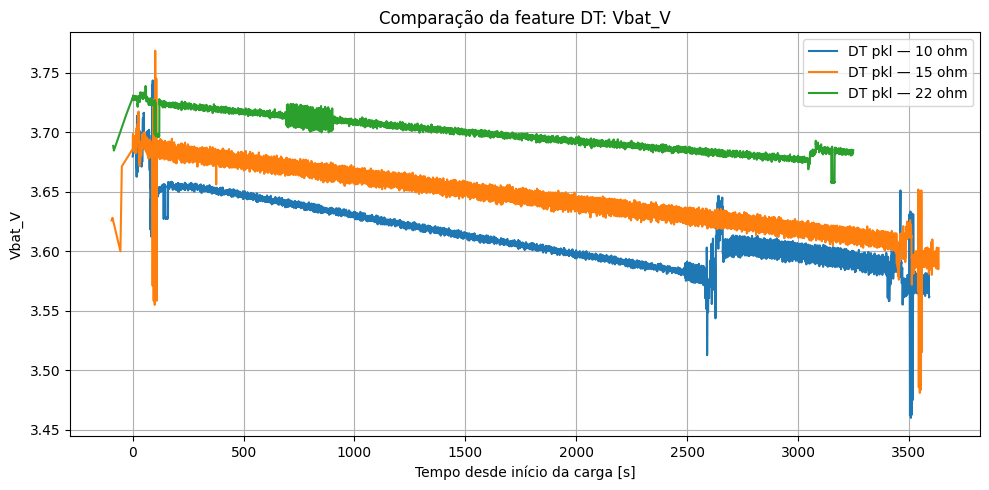

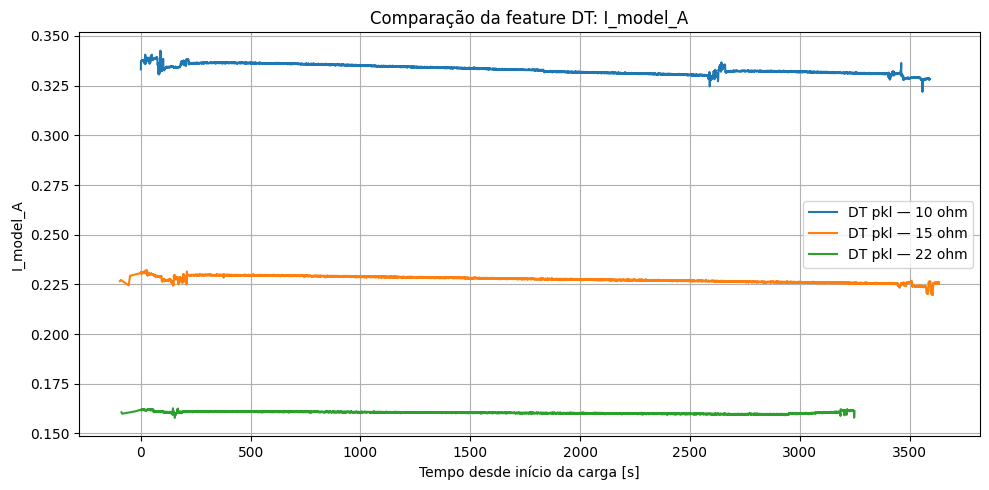

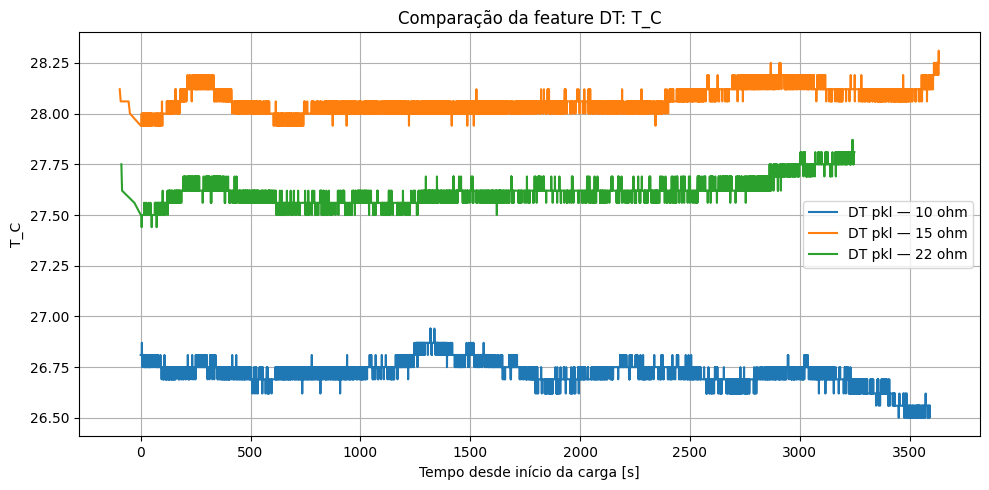

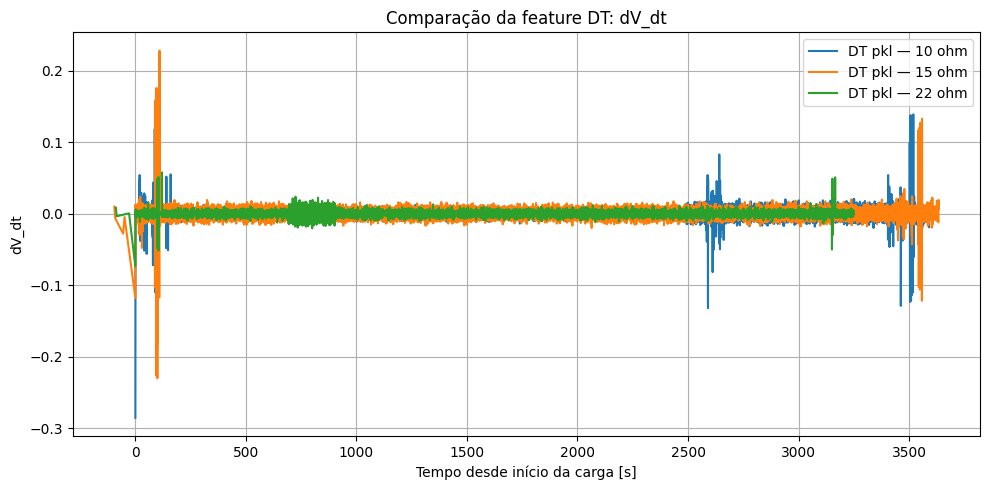

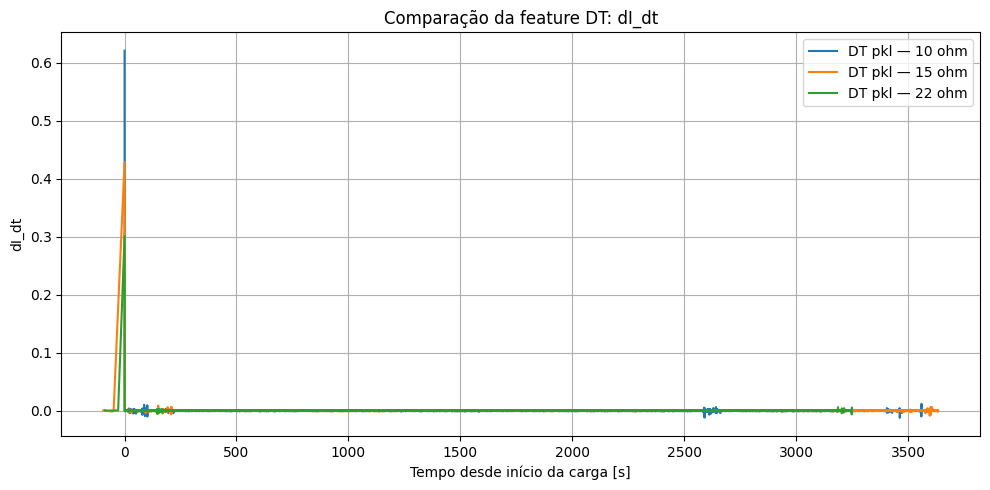

In [12]:
# ============================================================
# 12) GRÁFICOS DAS FEATURES DT POR ENSAIO
# ============================================================

FEATURES_DT = ["Vbat_V", "I_model_A", "T_C", "dV_dt", "dI_dt"]

for feature in FEATURES_DT:
    if feature not in df_all.columns:
        print(f"Feature não encontrada: {feature}")
        continue

    plt.figure(figsize=(10, 5))

    for nome, g in df_all.groupby("ensaio"):
        g_on = g[g["carga_ligada"]].sort_values("t_rel_carga_s")
        plt.plot(g_on["t_rel_carga_s"], g_on[feature], label=nome)

    plt.xlabel("Tempo desde início da carga [s]")
    plt.ylabel(feature)
    plt.title(f"Comparação da feature DT: {feature}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    nome_ficheiro = f"comparacao_feature_{feature}.png".replace("/", "_")
    plt.savefig(os.path.join(OUTPUT_DIR, nome_ficheiro), dpi=150)
    plt.show()

In [13]:
# ============================================================
# 13) GUARDAR TABELAS FINAIS
# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_all.to_csv(os.path.join(OUTPUT_DIR, "dados_todos_ensaios.csv"), index=False)
df_resumo.to_csv(os.path.join(OUTPUT_DIR, "resumo_ensaios.csv"), index=False)
df_metricas.to_csv(os.path.join(OUTPUT_DIR, "metricas_soc_ml_vs_soc_fw.csv"), index=False)

if "df_patamares" in globals():
    df_patamares.to_csv(os.path.join(OUTPUT_DIR, "tabela_patamares.csv"), index=False)

print("Ficheiros guardados em:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Ficheiros guardados em: resultados_validacao_DT_multiresistencia
['comparacao_feature_Vbat_V.png', 'comparacao_vbat_multiresistencia.png', 'resumo_ensaios.csv', 'comparacao_soc_fw_multiresistencia.png', 'tensao_DT_pkl_-_15_ohm.png', 'tabela_patamares.csv', 'soc_DT_pkl_-_22_ohm.png', 'comparacao_feature_I_model_A.png', 'comparacao_feature_dV_dt.png', 'tensao_DT_pkl_-_10_ohm.png', 'soc_DT_pkl_-_10_ohm.png', 'tensao_DT_pkl_-_22_ohm.png', 'dados_todos_ensaios.csv', 'metricas_soc_ml_vs_soc_fw.csv', 'corrente_DT_pkl_-_22_ohm.png', 'comparacao_soc_ml_multiresistencia.png', 'corrente_DT_pkl_-_10_ohm.png', 'corrente_DT_pkl_-_15_ohm.png', 'comparacao_feature_T_C.png', 'soc_DT_pkl_-_15_ohm.png', 'comparacao_feature_dI_dt.png', 'comparacao_corrente_multiresistencia.png']


In [14]:
# ============================================================
# 14) COMPARAÇÃO TEXTUAL ENTRE ENSAIOS
# ============================================================

print("Comparação entre ensaios:\n")

for _, row in df_resumo.iterrows():
    print(f"{row['ensaio']}:")
    print(f"  Resistência: {row['R_ohm']} Ω")
    print(f"  Corrente média com carga: {row['I_mA_medio_carga']:.1f} mA")
    print(f"  Duração com carga: {row['t_carga_s']:.1f} s")
    print(f"  Vbat início/fim: {row['Vbat_inicio_carga']:.4f} V → {row['Vbat_fim_carga']:.4f} V")
    print(f"  SoC_fw início/fim: {row['SoC_fw_inicio']:.4f} → {row['SoC_fw_fim']:.4f}")
    print(f"  SoC_ml início/fim: {row['SoC_ml_inicio']:.4f} → {row['SoC_ml_fim']:.4f}")
    print()

print("Interpretação geral:")
print(
    "Os ensaios com diferentes resistências permitem observar a resposta do sistema "
    "em regimes de descarga distintos. A resistência menor produz maior corrente e "
    "descarga mais rápida, enquanto a resistência maior produz corrente inferior e "
    "evolução mais lenta da tensão e do SoC."
)

Comparação entre ensaios:

DT pkl — 10 ohm:
  Resistência: 10 Ω
  Corrente média com carga: 333.2 mA
  Duração com carga: 3591.8 s
  Vbat início/fim: 3.6795 V → 3.5615 V
  SoC_fw início/fim: 0.6827 → 0.5549
  SoC_ml início/fim: 0.5237 → 0.7444

DT pkl — 15 ohm:
  Resistência: 15 Ω
  Corrente média com carga: 227.6 mA
  Duração com carga: 3729.9 s
  Vbat início/fim: 3.6858 V → 3.6025 V
  SoC_fw início/fim: 0.5957 → 0.5073
  SoC_ml início/fim: 0.5237 → 0.6460

DT pkl — 22 ohm:
  Resistência: 22 Ω
  Corrente média com carga: 160.4 mA
  Duração com carga: 3337.1 s
  Vbat início/fim: 3.7290 V → 3.6848 V
  SoC_fw início/fim: 0.6064 → 0.5507
  SoC_ml início/fim: 0.5237 → 0.5237

Interpretação geral:
Os ensaios com diferentes resistências permitem observar a resposta do sistema em regimes de descarga distintos. A resistência menor produz maior corrente e descarga mais rápida, enquanto a resistência maior produz corrente inferior e evolução mais lenta da tensão e do SoC.



## Interpretação para relatório

Os ensaios experimentais com diferentes cargas resistivas permitem comparar o comportamento do sistema em regimes de descarga distintos. A resistência de menor valor conduz a maior corrente e descarga mais rápida, enquanto a resistência de maior valor conduz a corrente inferior e evolução mais lenta da tensão e do SoC.

O `SoC_fw` é usado como referência interna baseada em OCV inicial e coulomb counting. O `SoC_ml` corresponde à estimativa produzida em tempo real pela Árvore de Decisão embarcada, convertida a partir do modelo `dt_soc_light_depth6.pkl`. A comparação entre `SoC_ml`, `SoC_fw` e `SoC_max` permite avaliar a integração do modelo no firmware e discutir a sua precisão experimental.

Os resultados devem ser interpretados como validação funcional da integração DT/SoC no ESP32, com análise crítica do erro observado e das limitações de generalização do modelo treinado offline para os dados reais da bancada.


In [15]:
# ============================================================
# 15) CONCLUSÃO TÉCNICA PARA RELATÓRIO
# ============================================================

texto_conclusao = """
A validação experimental foi realizada com diferentes cargas resistivas, permitindo
avaliar o funcionamento do firmware em regimes de descarga distintos. Em todos os
ensaios, o sistema registou tensão da célula, corrente, temperatura, SoC_fw por
coulomb counting, SoC_ml estimado pela Árvore de Decisão embarcada e SoC_max
fornecido pelo fuel gauge MAX17048.

A comparação entre os ensaios mostra coerência física entre a resistência aplicada
e a corrente medida: cargas de menor resistência conduzem a correntes superiores,
enquanto cargas de maior resistência originam descargas mais lentas. O SoC_fw
apresenta uma evolução contínua e coerente com a capacidade acumulada descarregada.

A componente DT/SoC foi integrada no firmware através da conversão do modelo
dt_soc_light_depth6.pkl para uma função C/C++ socModelPredict(). Os resultados
experimentais confirmam que a estimativa SoC_ml é calculada em tempo real no ESP32.
No entanto, a comparação com SoC_fw evidencia erro e comportamento discreto por
patamares, indicando limitações de generalização do modelo treinado offline para
os dados reais da bancada experimental.
"""

print(texto_conclusao)

with open(os.path.join(OUTPUT_DIR, "conclusao_tecnica.txt"), "w", encoding="utf-8") as f:
    f.write(texto_conclusao)


A validação experimental foi realizada com diferentes cargas resistivas, permitindo
avaliar o funcionamento do firmware em regimes de descarga distintos. Em todos os
ensaios, o sistema registou tensão da célula, corrente, temperatura, SoC_fw por
coulomb counting, SoC_ml estimado pela Árvore de Decisão embarcada e SoC_max
fornecido pelo fuel gauge MAX17048.

A comparação entre os ensaios mostra coerência física entre a resistência aplicada
e a corrente medida: cargas de menor resistência conduzem a correntes superiores,
enquanto cargas de maior resistência originam descargas mais lentas. O SoC_fw
apresenta uma evolução contínua e coerente com a capacidade acumulada descarregada.

A componente DT/SoC foi integrada no firmware através da conversão do modelo
dt_soc_light_depth6.pkl para uma função C/C++ socModelPredict(). Os resultados
experimentais confirmam que a estimativa SoC_ml é calculada em tempo real no ESP32.
No entanto, a comparação com SoC_fw evidencia erro e comportamento disc

In [16]:
# ============================================================
# 16) LISTAGEM FINAL DE OUTPUTS
# ============================================================

print("Outputs gerados:\n")

for file in os.listdir(OUTPUT_DIR):
    print(os.path.join(OUTPUT_DIR, file))

Outputs gerados:

resultados_validacao_DT_multiresistencia/comparacao_feature_Vbat_V.png
resultados_validacao_DT_multiresistencia/comparacao_vbat_multiresistencia.png
resultados_validacao_DT_multiresistencia/resumo_ensaios.csv
resultados_validacao_DT_multiresistencia/comparacao_soc_fw_multiresistencia.png
resultados_validacao_DT_multiresistencia/tensao_DT_pkl_-_15_ohm.png
resultados_validacao_DT_multiresistencia/tabela_patamares.csv
resultados_validacao_DT_multiresistencia/soc_DT_pkl_-_22_ohm.png
resultados_validacao_DT_multiresistencia/comparacao_feature_I_model_A.png
resultados_validacao_DT_multiresistencia/comparacao_feature_dV_dt.png
resultados_validacao_DT_multiresistencia/tensao_DT_pkl_-_10_ohm.png
resultados_validacao_DT_multiresistencia/soc_DT_pkl_-_10_ohm.png
resultados_validacao_DT_multiresistencia/tensao_DT_pkl_-_22_ohm.png
resultados_validacao_DT_multiresistencia/dados_todos_ensaios.csv
resultados_validacao_DT_multiresistencia/metricas_soc_ml_vs_soc_fw.csv
resultados_valida